## Calculation of the Current Carrying Capacity of Buried Cables with C4_open
### Example for an ac single-core cable system in pipe with cyclic loads

### Importing the modules

In [1]:
# Generic modules
import pandas as pd
import os

# C4 modules
from c4_open.project import Project
from c4_open.cables import Cable
from c4_open.cyclic_rating_factors import FactorM
from c4_open.load_profile import LoadProfile

# Import project directory
from c4_open.config import project_directory

### Defining the Project Data
The project data describes the arrangement of the cable and operational conditions. It is summarized in a dictionary with keys according to the following example. For the 'Calculation Case' one of the following values must be selected:

* *'ac_sc'*:      Calculation for ac single-core cables
* *'ac_sc_pipe'*: Calculation for ac single-core cables, laid in buried pipe
* *'dc_sc'*:      Calculation for dc single-core cables
* *'dc_sc_pipe'*: Calculation for dc single-core cables, laid in buried pipe
* *'ac_mc'*:      Calculation for ac multi-core cables
* *'ac_mc_pipe'*: Calculation for ac multi-core cables, laid in buried pipe

The optional values are only required for the calculation of cables in pipes (*N*, *dpipe_in*, *dpipe_out*, *rho_pipe* and *theta_mean*).

In [2]:
project_parameters = {'name': 'ac single-core cables in pipe with cyclic load',
                      'calc_case': 'ac_sc_scr_pipe',
                      'F': 1,               # Mutual heating factor F
                      'K': 3,              # Number of cables in pipe (optional)
                      'L': 0.7,             # Depth of laying
                      'N': 1,               # Total number of parallel cables (or pipes)
                      'U_0': 12000,         # Phase-ground voltage (only for ac cables)
                      'U_n': 20000,         # Phase-phase voltage (only for ac cables)
                      'f': 50.0,            # Mains frequency
                      'cable_type': 'NA2XS2Y 1x240 20kV',  # Cable type according to 'cable_data.xlsx'
                      'deltatheta_x': 15,   # Critical temperature rise of soil above drying of soil occurs
                      'dpipe_in': 138,       # Inner pipe diameter (optional)
                      'dpipe_out': 160,      # External pipe diameter (optional)   
                      'theta_mean': 55,     # Mean air temperature inside pipe (optional), 
                                            # a good assumption is mean of ambient temperature and max. conductor temperature  
                      'rho_T4': 1.0,          # Thermal resistivity of soil
                      'rho_pipe': 3.5,       # Thermal resistivity of pipe material (optional)
                      'theta_amb': 20.0,      # Ambient temperature          
                      }

### Create the project object

In [3]:
project = Project(**project_parameters)

### Create the load profile object
For the calculation of the load profile parameters the *LoadProfile* class can be used. It processes the parameters from data provided in an .xlsx., which must meet the following requirements:
* The column with the load profile data must be labeled with *'load'*
* Must comprise hourly values for one day, e.g. 24 values
The method *LoadProfile.get_parameters()* returns a dictionary with the required parameters. 

In [4]:
path = os.path.join(project_directory, './examples/example_load_profile.xlsx')
load_profile = LoadProfile(path)
load_profile_parameters = load_profile.get_parameters()

# Converted to DataFrame for better readability only
print(pd.DataFrame.from_dict(load_profile_parameters, orient='index'))

# Update the delta_theta_x of the project
project.get_delta_theta_x(load_profile)

                      0
Y_0            1.000000
Y_1            1.000000
Y_2            1.000000
Y_3            1.000000
Y_4            1.000000
Y_5            0.727687
mu             0.328415
m              0.398563
deltatheta_x  35.037858
Y_0_hour      13.000000


### Plotting load profile
The method *LoadProfile.get_results()* returns a DataFrame with the load profile parameters which can be plotted in a very simple way.

<Axes: >

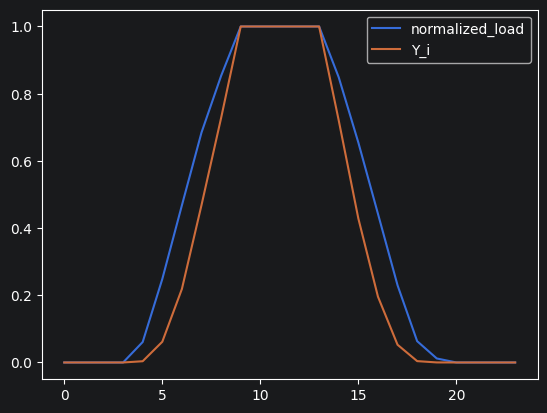

In [5]:
load_profile.get_results().plot()

### Create the cable object
To create a *cable* object the *project* object is required as the first argument. The optional argument *external_resistance_method* allows to chose a specific method to calculate the external thermal resistance of the cable *T_4*. Possible options are *'three_trefoil'*, *'three_flat'* and *'two_flat'* If no option is set, the default method *'from_F'* will be considered and the external thermal resistance will be calculated by using the mutual heating factor *F* as defined in the *project*.

The method Cable.get_result() will return a dictionary with the most relevant calculation results incl. two current carryng capacities. *I (no dryzone)* is 
calculated by ignoring a potentially arising dry zone while *I (with dryzone)* is the value considering a dry zone.

In [6]:
cable = Cable(project)
ampacities = cable.get_result()

# Converted to DataFrame for better readability only
print(pd.DataFrame.from_dict(ampacities, orient='index'))

Pipe Data 3.5 160.0
                                   0
Y_s                         0.003205
Y_p                         0.001732
R                           0.000161
W_d                         0.056096
lambda_1 (no dry zone)      0.026450
lambda_1 (with dry zone)    0.026305
T_1                         0.295938
T_3                         0.163799
T_4 (no dry zone)           0.862874
T_4 (with dry zone)         0.855900
I (no dry zone)           567.656731
I (with dry zone)         534.992766


### Calculating the Cyclic Rating Factor M
The *FactorM* class provides a simple interface to the different calculation functions depending on the calculation case. The method *FactorM.get_result()* returns a dictionary with the factors:
* *M (with dry zone)*:    Cyclic rating factor for current corresponding to a steady state current carrying capacity considering a dry zone around the cable  
* *M_1 (with dry zone)*:  Cyclic rating factor corrected for moisture migration for calculations considering a dry zone; in case the surface temperatur doesn't exceed the critical temperature rise (*delta_theta_x*), moisture migration will not occure and the method will return 'None' 
* *M (no dry zone)*:      Cyclic rating factor for current corresponding to a steady state current carrying capacity without considering a dry zone around the cable  


In [7]:
M = FactorM(cable, load_profile)
cyclic_rating_factors = M.get_result()
# Converted to DataFrame for better readability only
print(pd.DataFrame.from_dict(cyclic_rating_factors, orient='index')) 

                          0
M (with dry zone)  1.369777
M_1                1.399727
M (no dry zone)    1.452187


### Final Result
In this example case no value for *M_1* is returned. This means that no dry zone will occure around the pipe under the given cyclic load. Therefore the calculated current carrying capacity without considering a dry zone *I (no dry zone)* must be taken and multiplied with the value for *M (no dry zone)*. The result is the current carrying capacity of the cable under the given cyclic load.

In [8]:
I = ampacities['I (no dry zone)'] * cyclic_rating_factors['M (no dry zone)']
print('Current carrying capacity [A]:', round(I, 1))

Current carrying capacity [A]: 824.3


### Reports

In [9]:
report = cable.get_report()
print(pd.Series(report))

cable_type                  NA2XS2Y 1x240 20kV
theta_max                                 90.0
R__20                                 0.000125
alpha_con                                0.004
R_                                     0.00016
L                                          0.7
factor_F                                   1.0
rho_T4                                     1.0
theta_amb                                 20.0
deltatheta_x                         35.037858
C                                          0.0
R__scr20                              0.000741
alpha_scr                              0.00393
d_c                                       18.4
d_out                                     42.0
t_ins                                     6.45
t_sheath                                  5.35
n                                            1
rho_T1                                     3.5
rho_T3                                     3.5
K                                            3
Dpipe_in     

In [10]:
report = M.get_report()
print(pd.Series(report))

W            141.862620
L              0.700000
d_out        160.000000
rho_T4         1.000000
theta_amb     20.000000
theta_max     90.000000
mu             0.328415
Y_0            1.000000
Y_1            1.000000
Y_2            1.000000
Y_3            1.000000
Y_4            1.000000
Y_5            0.727687
k              0.923188
beta_1         0.046339
beta_2         0.110627
beta_3         0.159824
beta_4         0.198680
beta_5         0.230624
beta_6         0.257697
phi_0          0.046339
phi_1          0.064288
phi_2          0.049197
phi_3          0.038856
phi_4          0.031944
phi_5          0.027074
B                   NaN
M              1.369777
theta_SPK     59.911505
M_1            1.399727
dtype: float64
